In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import kind
import utils_data
import utils_plot

In [3]:
# --!--------------------------------------------------------------------------
# --! load trained models

model = torch.load('../../models/baselines/kind_tesla.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=25, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=300, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=6, out_features=6, bias=False)
    (mod_mean): Linear(in_features=6, out_features=6, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=18, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=144, bias=True

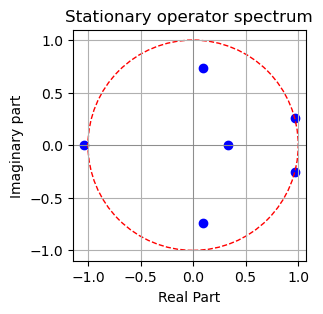

tensor([-1.0415+0.0000j,  0.0912+0.7363j,  0.0912-0.7363j,  0.9688+0.2562j,
         0.9688-0.2562j,  0.3315+0.0000j])


In [4]:
# --!--------------------------------------------------------------------------!
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

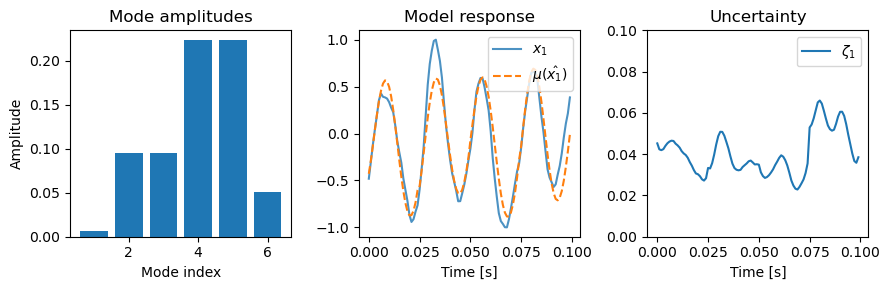

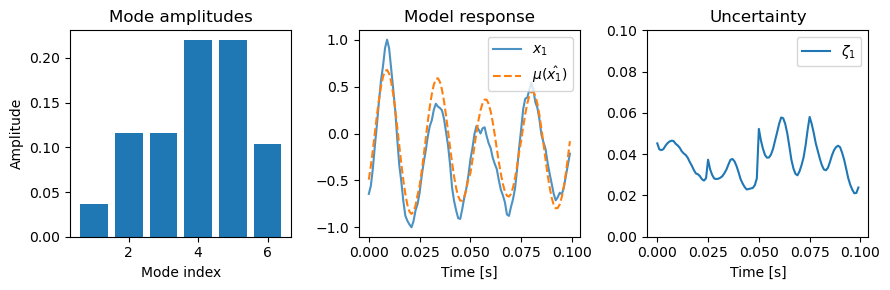

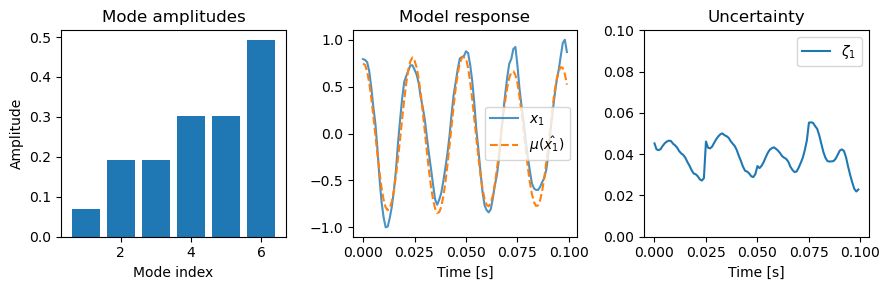

In [5]:
# --!--------------------------------------------------------------------------!
# --! analyze the contribution of stationary operator eigenvalues

datadir            = '../../data/baselines/train_tesla_stat'
timeseries_nsample = 100

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

In [6]:
# --! make forecasts in a manner of a sliding window --!

datadir            = '../../data/baselines/test_tesla'
timeseries_nsample = 100
mse                = utils_plot.plot_mse(model, datadir, timeseries_nsample)


inf >> evaluation results:

       mse      index      value
  --------   --------   --------
      best         66      0.007
     worst        664      0.278
       avg         na      0.074



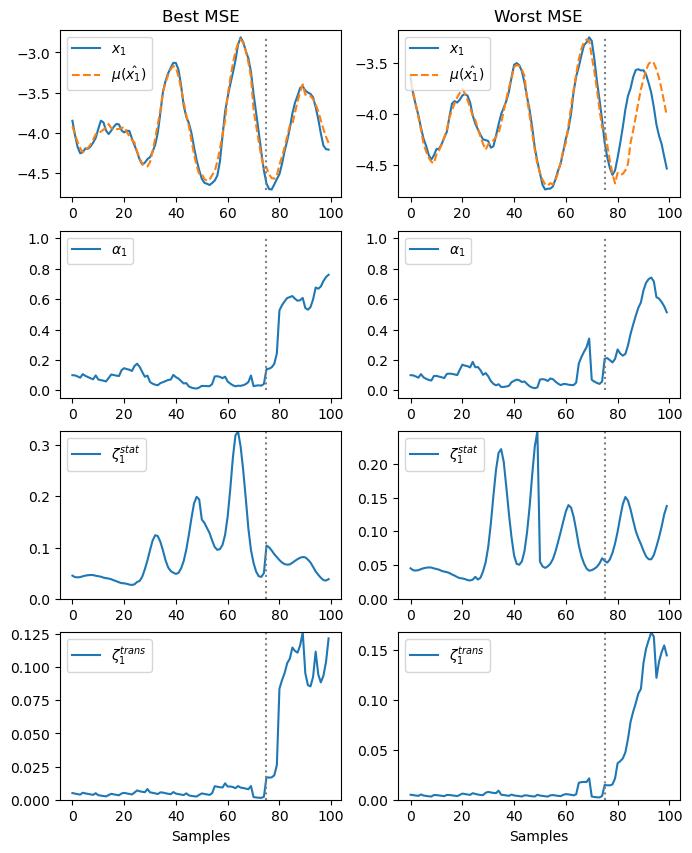

In [7]:
utils_plot.plot_mse_extreme(model, mse, datadir, timeseries_nsample)